# 第5章：Pretraining on Unlabeled Data

**目标：** 训练第4章搭建的 GPT 模型，让它真正学会生成有意义的文本，并加载 OpenAI 发布的 GPT-2 预训练权重

```
评估模型(loss) → 训练循环 → 解码策略(temperature/top-k) → 加载 GPT-2 权重 → 生成真正的文本
```

**前置回顾（第2-4章）：**
- 第2章：文本 → Token IDs → DataLoader（batch + sliding window）
- 第3章：Multi-Head Causal Attention 让每个 token 融合上下文
- 第4章：完整 GPT 模型 + Greedy Decoding 文本生成
- 现在的问题：模型权重是随机初始化的，生成的文本毫无意义 → **需要训练！**

---

## 5.1 评估模型：交叉熵损失 ⭐

在训练之前，我们先搞清楚如何**衡量模型的好坏**。

GPT 的训练目标是**下一个 token 预测（Next Token Prediction）**：
- 给定 `[t₁, t₂, ..., tₙ]`，模型需要预测 `[t₂, t₃, ..., tₙ₊₁]`
- 每个位置输出一个 `vocab_size` 维的 logits 向量
- 通过 softmax 转成概率分布，用**交叉熵损失**衡量与真实 token 的差距

**交叉熵损失（Cross-Entropy Loss）：**

$$L = -\frac{1}{N}\sum_{i=1}^{N} \log P(t_i^{\text{target}} | t_1, ..., t_{i-1})$$

- 如果模型对正确 token 给出高概率 → 损失小
- 如果模型对正确 token 给出低概率 → 损失大

**与困惑度（Perplexity）的关系：**

$$\text{Perplexity} = e^{\text{Cross-Entropy Loss}}$$

- 困惑度可以理解为「模型在每个位置平均犹豫多少个 token」
- 随机猜测时，perplexity ≈ vocab_size（50,257）
- 训练良好的模型，perplexity 通常在 10-50 之间

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# ─── 第4章的所有组件（直接复用）───────────────────────────────────

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False,
}


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(), -torch.inf
        )
        attn_weights = F.softmax(attn_scores / self.head_dim**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vecs = attn_weights @ values
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        context_vecs = self.out_proj(context_vecs)
        return context_vecs


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


# ─── 初始化 ──────────────────────────────────────────────────────
tokenizer = tiktoken.get_encoding("gpt2")
print("第4章组件加载完毕 ✓")
print(f"GPT-2 124M 配置: {GPT_CONFIG_124M}")

第4章组件加载完毕 ✓
GPT-2 124M 配置: {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}


In [2]:
# 用两个简单句子直观理解交叉熵损失
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch = torch.stack([
    torch.tensor(tokenizer.encode(txt1)),
    torch.tensor(tokenizer.encode(txt2)),
], dim=0)
print(f"输入 batch shape: {batch.shape}")
print(f"  txt1 tokens: {tokenizer.encode(txt1)}")
print(f"  txt2 tokens: {tokenizer.encode(txt2)}")

输入 batch shape: torch.Size([2, 4])
  txt1 tokens: [6109, 3626, 6100, 345]
  txt2 tokens: [6109, 1110, 6622, 257]


In [3]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

logits = model(batch)
print(f"logits shape: {logits.shape}")
print(f"→ (batch=2, seq_len=4, vocab_size=50257)")

logits shape: torch.Size([2, 4, 50257])
→ (batch=2, seq_len=4, vocab_size=50257)


### 从 logits 到损失

**训练目标**是让模型预测序列中的下一个 token：
```
输入:  [Every,  effort, moves, you]
目标:  [effort, moves,  you,   <end>]
```

对于我们的两句话：
- 输入 `[Every, effort, moves]` → 目标 `[effort, moves, you]`
- 输入 `[Every, day, holds]` → 目标 `[day, holds, a]`

In [4]:
# 构造输入和目标
inputs = batch[:, :-1]   # 去掉最后一个 token
targets = batch[:, 1:]   # 去掉第一个 token（向右移一位）

print(f"inputs:  {inputs.shape}")
print(f"targets: {targets.shape}")
print(f"\n输入tokens:")
for i, row in enumerate(inputs):
    print(f"  句子{i+1}: {[tokenizer.decode([t.item()]) for t in row]}")
print(f"目标tokens:")
for i, row in enumerate(targets):
    print(f"  句子{i+1}: {[tokenizer.decode([t.item()]) for t in row]}")

inputs:  torch.Size([2, 3])
targets: torch.Size([2, 3])

输入tokens:
  句子1: ['Every', ' effort', ' moves']
  句子2: ['Every', ' day', ' holds']
目标tokens:
  句子1: [' effort', ' moves', ' you']
  句子2: [' day', ' holds', ' a']


In [5]:
# 手动计算交叉熵损失
with torch.no_grad():
    logits = model(inputs)

print(f"logits shape: {logits.shape}")

# 展平: (batch*seq_len, vocab_size) 和 (batch*seq_len,)
logits_flat = logits.flatten(0, 1)     # (6, 50257)
targets_flat = targets.flatten()        # (6,)
print(f"展平后 logits: {logits_flat.shape}")
print(f"展平后 targets: {targets_flat.shape}")

loss = F.cross_entropy(logits_flat, targets_flat)
print(f"\n交叉熵损失: {loss.item():.4f}")

perplexity = torch.exp(loss)
print(f"困惑度 (Perplexity): {perplexity.item():.2f}")
print(f"\n→ 随机猜测时 perplexity ≈ vocab_size = {GPT_CONFIG_124M['vocab_size']}")
print(f"→ 当前 perplexity = {perplexity.item():.0f}，说明模型完全没学到东西（符合预期）")

logits shape: torch.Size([2, 3, 50257])
展平后 logits: torch.Size([6, 50257])
展平后 targets: torch.Size([6])

交叉熵损失: 11.1666
困惑度 (Perplexity): 70725.68

→ 随机猜测时 perplexity ≈ vocab_size = 50257
→ 当前 perplexity = 70726，说明模型完全没学到东西（符合预期）


> 💡 **关键洞察：** 未训练模型的 perplexity ≈ vocab_size，因为它对每个 token 几乎等概率猜测。
> 训练的目标就是**降低这个损失**，让模型对正确的下一个 token 给出更高的概率。

### ✏️ 练习
1. 手动验证：`F.cross_entropy` 的结果等价于先 softmax 再取 `-log`。用 `logits_flat[0]` 和 `targets_flat[0]` 手动算一遍。
2. 如果模型对正确 token 的概率是 0.5，交叉熵损失是多少？概率是 0.01 呢？

In [6]:
# 练习 1: 手动验证 cross entropy = -log(正确类别概率)
sample_logits = logits_flat[0]
sample_target = targets_flat[0].item()
sample_probs = torch.softmax(sample_logits, dim=0)
target_prob = sample_probs[sample_target]
manual_ce = -torch.log(target_prob)
api_ce = F.cross_entropy(sample_logits.unsqueeze(0), targets_flat[0].unsqueeze(0))

print("【手动验证交叉熵】")
print(f"目标 token id: {sample_target}")
print(f"目标 token 文本: {tokenizer.decode([sample_target])!r}")
print(f"softmax 后正确类别概率: {target_prob.item():.8f}")
print(f"手动计算 -log(p): {manual_ce.item():.8f}")
print(f"F.cross_entropy:  {api_ce.item():.8f}")
print(f"两者差值: {(manual_ce - api_ce).abs().item():.10f}")

# 练习 2: 不同正确概率对应的交叉熵
print("\n【概率与交叉熵的关系】")
for p in [0.5, 0.01]:
    ce = -torch.log(torch.tensor(p))
    print(f"正确概率 = {p:<4}: 交叉熵 = {ce.item():.4f}")

print("→ 概率越低，交叉熵越大；模型越自信且预测错误，惩罚越重。")

【手动验证交叉熵】
目标 token id: 3626
目标 token 文本: ' effort'
softmax 后正确类别概率: 0.00002468
手动计算 -log(p): 10.60942936
F.cross_entropy:  10.60942936
两者差值: 0.0000000000

【概率与交叉熵的关系】
正确概率 = 0.5 : 交叉熵 = 0.6931
正确概率 = 0.01: 交叉熵 = 4.6052
→ 概率越低，交叉熵越大；模型越自信且预测错误，惩罚越重。


---
## 5.2 准备训练数据 ⭐

我们将使用第2章的方法，将文本加载为训练用的 DataLoader。

为了演示训练过程，我们使用 Edith Wharton 的短篇小说 *The Verdict* 作为训练数据（约 20KB）。

**为什么用这么小的数据集？**
- 真正的 GPT 预训练需要数十 GB 数据和数千 GPU 小时
- 这里用小数据集是为了**在几分钟内走通整个训练流程**
- 理解了训练流程后，第 5.5 节我们会加载 OpenAI 发布的 GPT-2 预训练权重

In [4]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

# 优先使用本地 data 目录中的文件
local_data_path = os.path.join("..", "data", "the-verdict.txt")
if os.path.exists(local_data_path):
    file_path = local_data_path
    print(f"使用本地文件: {file_path}")
elif not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)
    print(f"已下载: {file_path}")

with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

total_characters = len(raw_text)
total_tokens = len(tokenizer.encode(raw_text))

print(f"\n文本长度: {total_characters:,} 字符")
print(f"Token 数量: {total_tokens:,}")
print(f"前 200 字符: {raw_text[:200]}...")

NameError: name 'tokenizer' is not defined

In [8]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    """第2章实现的 GPT 数据集：用滑动窗口将文本切分为 (input, target) 对"""
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1:i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )
    return dataloader

In [9]:
# 划分训练集和验证集（90% / 10%）
train_ratio = 0.90
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]

print(f"训练集: {len(train_data):,} 字符")
print(f"验证集: {len(val_data):,} 字符")

训练集: 18,431 字符
验证集: 2,048 字符


In [10]:
# 创建 DataLoader
# 使用较小的 context_length 以加快训练（真实 GPT-2 用 1024）
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=256,
    stride=128,
    shuffle=False,
    drop_last=False,
)

print(f"训练 batches: {len(train_loader)}")
print(f"验证 batches: {len(val_loader)}")

# 检查一个 batch
for x, y in train_loader:
    print(f"\n第一个 batch:")
    print(f"  x shape: {x.shape}")
    print(f"  y shape: {y.shape}")
    break

# token 总量
train_tokens = 0
for x, y in train_loader:
    train_tokens += x.numel()
val_tokens = 0
for x, y in val_loader:
    val_tokens += x.numel()
print(f"\n训练 tokens: {train_tokens:,}")
print(f"验证 tokens: {val_tokens:,}")

训练 batches: 17
验证 batches: 2

第一个 batch:
  x shape: torch.Size([2, 256])
  y shape: torch.Size([2, 256])

训练 tokens: 8,704
验证 tokens: 768


> 💡 **关键参数说明：**
> - `max_length=256`：每个样本的序列长度（比 GPT-2 的 1024 小，加速训练）
> - `stride=128`：滑动窗口步长（小于 max_length，产生重叠样本，增大训练数据量）
> - `drop_last=True`：丢弃最后不完整的 batch，保证所有 batch 大小一致

### ✏️ 练习
1. 改变 `stride` 的值（设为 256 即无重叠），观察训练 batches 数量的变化。
2. 如果 `max_length=1024`（GPT-2 原始设置），训练 batches 会变成多少？

In [11]:
def count_batches_for_setting(txt, batch_size, max_length, stride, drop_last=True):
    loader = create_dataloader_v1(
        txt,
        batch_size=batch_size,
        max_length=max_length,
        stride=stride,
        shuffle=False,
        drop_last=drop_last,
    )
    num_samples = len(loader.dataset)
    num_batches = len(loader)
    return num_samples, num_batches


settings = [
    (256, 128),
    (256, 256),
    (1024, 1024),
]

print("【不同滑动窗口设置下的训练集规模】")
print(f"{'max_length':<12}{'stride':<10}{'samples':<10}{'batches':<10}")
for max_length, stride in settings:
    samples, batches = count_batches_for_setting(
        train_data,
        batch_size=2,
        max_length=max_length,
        stride=stride,
        drop_last=True,
    )
    print(f"{max_length:<12}{stride:<10}{samples:<10}{batches:<10}")

samples_overlap, batches_overlap = count_batches_for_setting(train_data, 2, 256, 128, True)
samples_no_overlap, batches_no_overlap = count_batches_for_setting(train_data, 2, 256, 256, True)
samples_1024, batches_1024 = count_batches_for_setting(train_data, 2, 1024, 1024, True)

print("\n【结论】")
print(f"stride 从 128 改成 256 后，batch 数从 {batches_overlap} 变成 {batches_no_overlap}。")
print("→ stride 越小，窗口重叠越多，样本数和 batch 数越大。")
print(f"如果 max_length=1024，训练 batches = {batches_1024}。")

【不同滑动窗口设置下的训练集规模】
max_length  stride    samples   batches   
256         128       35        17        
256         256       18        9         
1024        1024      4         2         

【结论】
stride 从 128 改成 256 后，batch 数从 17 变成 9。
→ stride 越小，窗口重叠越多，样本数和 batch 数越大。
如果 max_length=1024，训练 batches = 2。


---
## 5.3 训练循环 ⭐⭐⭐

现在进入本章最核心的部分——**训练循环**。

GPT 的训练流程和标准深度学习训练完全一样：

```
for epoch in epochs:
    for batch in train_loader:
        1. 前向传播：logits = model(inputs)
        2. 计算损失：loss = cross_entropy(logits, targets)
        3. 反向传播：loss.backward()
        4. 更新参数：optimizer.step()
```

**训练策略：**
- 优化器：AdamW（Adam + weight decay，LLM 标准优化器）
- 学习率：`5e-4`（GPT-2 原论文使用的学习率量级）
- Weight Decay：`0.1`（防止过拟合的正则化）
- 训练过程中定期评估验证集损失，确认模型没有过拟合

In [12]:
def calc_loss_batch(input_batch, target_batch, model, device):
    """计算单个 batch 的交叉熵损失"""
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = F.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """计算整个 DataLoader 的平均损失"""
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()

    return total_loss / num_batches

In [13]:
# 评估未训练模型的损失
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.eval()

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print(f"\n训练集损失: {train_loss:.4f}")
print(f"验证集损失: {val_loss:.4f}")
print(f"\n→ 未训练模型的损失 ≈ ln(50257) ≈ {torch.log(torch.tensor(50257.)).item():.2f}")
print(f"→ 这说明模型在随机猜测")

使用设备: cpu

训练集损失: 10.9873
验证集损失: 11.0008

→ 未训练模型的损失 ≈ ln(50257) ≈ 10.82
→ 这说明模型在随机猜测


In [14]:
def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context,
                       tokenizer):
    """简单的训练循环"""
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            tokens_seen += input_batch.numel()
            global_step += 1

            # 定期评估
            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_loss = calc_loss_loader(
                        train_loader, model, device, num_batches=eval_iter
                    )
                    val_loss = calc_loss_loader(
                        val_loader, model, device, num_batches=eval_iter
                    )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}")
                model.train()

        # 每个 epoch 结束后生成示例文本
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def generate_and_print_sample(model, tokenizer, device, start_context):
    """用当前模型生成示例文本"""
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = tokenizer.encode(start_context)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded_tensor,
            max_new_tokens=50, context_size=context_size,
        )
    decoded_text = tokenizer.decode(token_ids.squeeze(0).tolist())
    print(f"  → 生成: {decoded_text}")
    model.train()

In [15]:
# 🚀 开始训练！
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1,
)

num_epochs = 10

print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"训练 epochs: {num_epochs}")
print(f"设备: {device}")
print("=" * 60)

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer,
)

模型参数量: 163,009,536
训练 epochs: 10
设备: cpu
Ep 1 (Step 000000): Train loss 10.083, Val loss 10.054
Ep 1 (Step 000005): Train loss 8.144, Val loss 8.414
Ep 1 (Step 000010): Train loss 6.782, Val loss 7.112
Ep 1 (Step 000015): Train loss 6.202, Val loss 6.688
  → 生成: Every effort moves you, a, a, a, a, and, a, and, a, a, a, and, and, and, and, and, and, and, a, and, a, a, and, and, and, and
Ep 2 (Step 000020): Train loss 5.890, Val loss 6.602
Ep 2 (Step 000025): Train loss 5.631, Val loss 6.472
Ep 2 (Step 000030): Train loss 5.587, Val loss 6.359
  → 生成: Every effort moves you, and to the of the of the of the of the.





































Ep 3 (Step 000035): Train loss 5.250, Val loss 6.270
Ep 3 (Step 000040): Train loss 4.869, Val loss 6.239
Ep 3 (Step 000045): Train loss 4.657, Val loss 6.297
Ep 3 (Step 000050): Train loss 4.442, Val loss 6.148
  → 生成: Every effort moves you know.



" to the. Gisburn's the. Gisburn's the.





" to the first, in the first, in the. Gisburn'

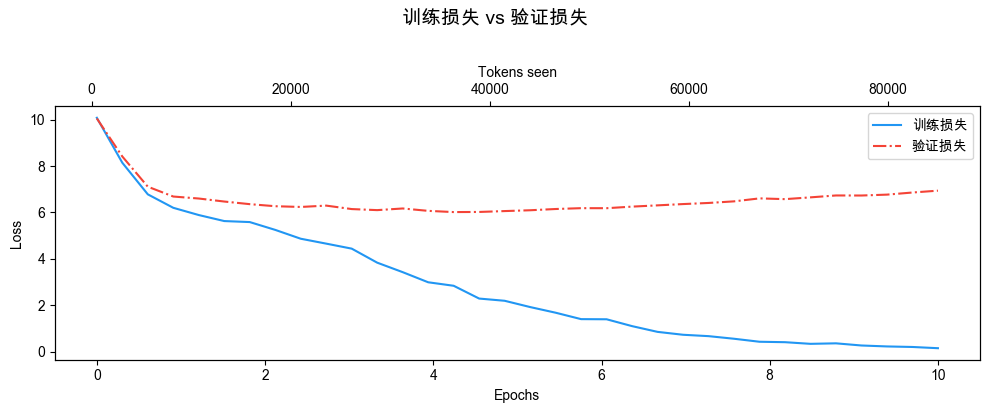

In [16]:
# 可视化训练过程
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(epochs_seen, train_losses, label="训练损失", color="#2196F3")
    ax1.plot(epochs_seen, val_losses, label="验证损失",
             linestyle="-.", color="#F44336")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")

    fig.suptitle("训练损失 vs 验证损失", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

> 💡 **关键观察：**
> - **训练损失持续下降** → 模型在学习训练数据中的模式
> - **验证损失先降后升（可能）** → 过拟合的信号！
> - 这是因为我们用了非常小的数据集（~5K tokens）来训练一个 1.24 亿参数的模型
> - 在真实场景中，GPT-2 使用了 ~9B tokens 训练，不容易过拟合
>
> **过拟合不是我们的重点**——本章的目标是走通训练流程，然后在 5.5 节加载预训练权重。

### ✏️ 练习
1. 修改 `num_epochs=20`，观察验证损失的变化趋势。什么时候开始明显过拟合？
2. 改变学习率（试试 `1e-3` 和 `1e-5`），观察对训练的影响。
3. （进阶）在训练循环中加入 **梯度裁剪**（`torch.nn.utils.clip_grad_norm_`），这是 LLM 训练中常用的技巧。

In [17]:
# 为了让练习更快，这里用更小的 GPT 配置对比超参数效果。
EXPERIMENT_CONFIG = {
    **GPT_CONFIG_124M,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "context_length": 256,
    "drop_rate": 0.1,
}


def train_model_with_optional_clipping(model, train_loader, val_loader, optimizer, device,
                                      num_epochs, eval_freq, eval_iter, grad_clip=None):
    train_losses, val_losses = [], []
    global_step = -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()

            global_step += 1
            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
                    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                model.train()

    return train_losses, val_losses


def run_training_experiment(label, lr, num_epochs=20, grad_clip=None):
    torch.manual_seed(123)
    exp_model = GPTModel(EXPERIMENT_CONFIG).to(device)
    optimizer = torch.optim.AdamW(exp_model.parameters(), lr=lr, weight_decay=0.1)
    train_losses_exp, val_losses_exp = train_model_with_optional_clipping(
        exp_model,
        train_loader,
        val_loader,
        optimizer,
        device,
        num_epochs=num_epochs,
        eval_freq=5,
        eval_iter=3,
        grad_clip=grad_clip,
    )
    best_val = min(val_losses_exp)
    best_step = val_losses_exp.index(best_val)
    final_train = train_losses_exp[-1]
    final_val = val_losses_exp[-1]
    print(f"\n【{label}】 lr={lr}, epochs={num_epochs}, grad_clip={grad_clip}")
    print(f"  首次评估: train={train_losses_exp[0]:.3f}, val={val_losses_exp[0]:.3f}")
    print(f"  最佳验证损失: {best_val:.3f} (第 {best_step + 1} 次评估)")
    print(f"  最终损失: train={final_train:.3f}, val={final_val:.3f}")
    print(f"  最终泛化差距 val-train = {final_val - final_train:.3f}")
    return {
        "label": label,
        "train_losses": train_losses_exp,
        "val_losses": val_losses_exp,
    }


experiments = []
experiments.append(run_training_experiment("baseline", lr=4e-4, num_epochs=20, grad_clip=None))
experiments.append(run_training_experiment("high_lr", lr=1e-3, num_epochs=20, grad_clip=None))
experiments.append(run_training_experiment("low_lr", lr=1e-5, num_epochs=20, grad_clip=None))
experiments.append(run_training_experiment("baseline+clip", lr=4e-4, num_epochs=20, grad_clip=1.0))

print("\n【观察建议】")
print("1. 看 val loss 的最低点之后是否回升，这通常意味着开始过拟合。")
print("2. lr=1e-3 往往下降更快，但也可能更不稳定。")
print("3. lr=1e-5 往往学习很慢。")
print("4. 加梯度裁剪后，训练通常更稳，尤其在更深/更大的模型里更重要。")


【baseline】 lr=0.0004, epochs=20, grad_clip=None
  首次评估: train=10.971, val=10.969
  最佳验证损失: 6.176 (第 66 次评估)
  最终损失: train=4.226, val=6.178
  最终泛化差距 val-train = 1.952

【high_lr】 lr=0.001, epochs=20, grad_clip=None
  首次评估: train=10.935, val=10.931
  最佳验证损失: 6.095 (第 37 次评估)
  最终损失: train=0.853, val=6.724
  最终泛化差距 val-train = 5.871

【low_lr】 lr=1e-05, epochs=20, grad_clip=None
  首次评估: train=10.994, val=10.994
  最佳验证损失: 10.677 (第 68 次评估)
  最终损失: train=10.596, val=10.677
  最终泛化差距 val-train = 0.080

【baseline+clip】 lr=0.0004, epochs=20, grad_clip=1.0
  首次评估: train=10.971, val=10.969
  最佳验证损失: 6.172 (第 66 次评估)
  最终损失: train=4.186, val=6.175
  最终泛化差距 val-train = 1.989

【观察建议】
1. 看 val loss 的最低点之后是否回升，这通常意味着开始过拟合。
2. lr=1e-3 往往下降更快，但也可能更不稳定。
3. lr=1e-5 往往学习很慢。
4. 加梯度裁剪后，训练通常更稳，尤其在更深/更大的模型里更重要。


---
## 5.4 解码策略：Temperature 和 Top-k 采样 ⭐⭐

第4章的 `generate_text_simple` 使用 **Greedy Decoding**（每次选概率最高的 token）。

这种方式的问题：
- 生成结果**确定性**的——同一个输入总是得到相同的输出
- 容易产生**重复**（模型陷入循环）
- 文本不够多样和有趣

**解决方案：引入随机性！**

### Temperature Scaling

在 softmax 之前，将 logits 除以一个 **temperature** 参数 $T$：

$$P(t_i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

| Temperature | 效果 |
|:-----------:|------|
| $T = 1$ | 标准 softmax，正常概率分布 |
| $T < 1$ | 分布更尖锐，高概率 token 更突出 → 更保守 |
| $T > 1$ | 分布更平缓，低概率 token 也有机会 → 更有创意 |
| $T → 0$ | 退化为 greedy（只选最大的） |
| $T → ∞$ | 均匀分布（完全随机） |

### Top-k 采样

只保留概率最高的 $k$ 个 token，其余的概率设为 0 后重新归一化。

```
原始概率:  [0.3, 0.25, 0.15, 0.1, 0.08, 0.07, 0.05]
Top-3后:   [0.43, 0.36, 0.21, 0,   0,    0,    0   ]  ← 只保留前3个
```

**组合使用：** 实际中通常 Temperature + Top-k 一起使用，效果最好。

In [18]:
# 直观理解 Temperature 的效果
vocab = {0: "every", 1: "effort", 2: "moves", 3: "you", 4: "forward"}
inverse_vocab = {v: k for k, v in vocab.items()}

# 模拟一组 logits
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63])

print("不同 Temperature 下的概率分布:")
print(f"{'Token':<10} {'logits':<8}", end="")

temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]
for t in temperatures:
    print(f"{'T='+str(t):<8}", end="")
print()

for i in range(len(vocab)):
    print(f"{vocab[i]:<10} {next_token_logits[i].item():<8.2f}", end="")
    for t in temperatures:
        probas = torch.softmax(next_token_logits / t, dim=0)
        print(f"{probas[i].item():<8.3f}", end="")
    print()

不同 Temperature 下的概率分布:
Token      logits  T=0.1   T=0.5   T=1.0   T=2.0   T=5.0   
every      4.51    0.000   0.011   0.095   0.222   0.257   
effort     0.89    0.000   0.000   0.003   0.036   0.125   
moves      -1.90   0.000   0.000   0.000   0.009   0.071   
you        6.75    1.000   0.989   0.896   0.680   0.402   
forward    1.63    0.000   0.000   0.005   0.053   0.145   


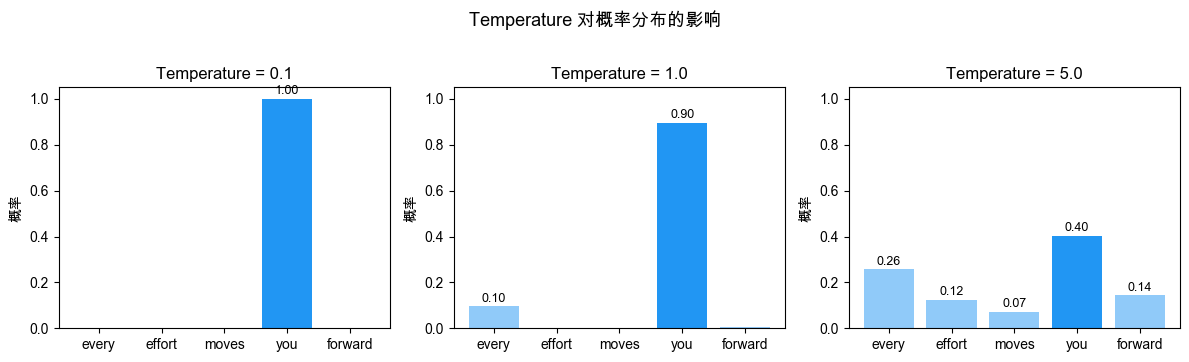

→ T=0.1: 几乎只选 'you'（最确定）
→ T=1.0: 正常分布，'you' 最高但其他也有概率
→ T=5.0: 接近均匀分布（最随机）


In [19]:
# 可视化 Temperature 效果
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
temperatures_vis = [0.1, 1.0, 5.0]

for ax, t in zip(axes, temperatures_vis):
    probas = torch.softmax(next_token_logits / t, dim=0)
    bars = ax.bar(
        [vocab[i] for i in range(len(vocab))],
        probas.numpy(),
        color=["#2196F3" if i == probas.argmax() else "#90CAF9" for i in range(len(vocab))]
    )
    ax.set_title(f"Temperature = {t}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("概率")
    for bar, p in zip(bars, probas):
        if p > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{p:.2f}", ha="center", fontsize=9)

plt.suptitle("Temperature 对概率分布的影响", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print("→ T=0.1: 几乎只选 'you'（最确定）")
print("→ T=1.0: 正常分布，'you' 最高但其他也有概率")
print("→ T=5.0: 接近均匀分布（最随机）")

In [20]:
# Top-k 采样的实现
def top_k_logits(logits, k):
    """只保留 top-k 个 logits，其余设为 -inf"""
    top_k_values, _ = torch.topk(logits, k)
    min_val = top_k_values[:, -1]  # 第 k 大的值
    logits = torch.where(
        logits < min_val,
        torch.tensor(float("-inf")),
        logits
    )
    return logits


# 演示 Top-k
logits_example = torch.tensor([[4.51, 0.89, -1.90, 6.75, 1.63]])

print("原始 logits:", logits_example)
print()

for k in [5, 3, 1]:
    filtered = top_k_logits(logits_example, k)
    probas = torch.softmax(filtered, dim=-1)
    print(f"Top-{k}: logits={filtered.tolist()[0]}")
    print(f"        probas={[f'{p:.3f}' for p in probas.tolist()[0]]}")
    print()

原始 logits: tensor([[ 4.5100,  0.8900, -1.9000,  6.7500,  1.6300]])

Top-5: logits=[4.510000228881836, 0.8899999856948853, -1.899999976158142, 6.75, 1.6299999952316284]
        probas=['0.095', '0.003', '0.000', '0.896', '0.005']

Top-3: logits=[4.510000228881836, -inf, -inf, 6.75, 1.6299999952316284]
        probas=['0.096', '0.000', '0.000', '0.899', '0.005']

Top-1: logits=[-inf, -inf, -inf, 6.75, -inf]
        probas=['0.000', '0.000', '0.000', '1.000', '0.000']



In [21]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=1.0, top_k=None, eos_id=None):
    """带 temperature 和 top-k 的文本生成"""
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]  # 只取最后一个位置

        # Top-k 过滤
        if top_k is not None:
            logits = top_k_logits(logits, top_k)

        # Temperature scaling
        if temperature > 0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # 遇到 EOS 则停止
        if eos_id is not None and idx_next.item() == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [22]:
# 用训练后的模型对比不同解码策略
model.eval()

start_context = "Every effort moves you"
encoded = torch.tensor(tokenizer.encode(start_context)).unsqueeze(0).to(device)

print("="*70)
print(f"输入: '{start_context}'")
print("="*70)

# Greedy
torch.manual_seed(123)
out = generate(model, encoded, max_new_tokens=25,
               context_size=GPT_CONFIG_124M["context_length"],
               temperature=0)
print(f"\n🔹 Greedy (T=0):")
print(f"   {tokenizer.decode(out.squeeze().tolist())}")

# Temperature = 0.5
torch.manual_seed(123)
out = generate(model, encoded, max_new_tokens=25,
               context_size=GPT_CONFIG_124M["context_length"],
               temperature=0.5)
print(f"\n🔹 T=0.5 (保守):")
print(f"   {tokenizer.decode(out.squeeze().tolist())}")

# Temperature = 1.0
torch.manual_seed(123)
out = generate(model, encoded, max_new_tokens=25,
               context_size=GPT_CONFIG_124M["context_length"],
               temperature=1.0)
print(f"\n🔹 T=1.0 (标准):")
print(f"   {tokenizer.decode(out.squeeze().tolist())}")

# Temperature = 1.0 + Top-k = 10
torch.manual_seed(123)
out = generate(model, encoded, max_new_tokens=25,
               context_size=GPT_CONFIG_124M["context_length"],
               temperature=1.0, top_k=10)
print(f"\n🔹 T=1.0 + Top-10:")
print(f"   {tokenizer.decode(out.squeeze().tolist())}")

输入: 'Every effort moves you'

🔹 Greedy (T=0):
   Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"



🔹 T=0.5 (保守):
   Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"



🔹 T=1.0 (标准):
   Every effort moves you?"

"Yes--quite insensible to the portraitition arm-room. She couldn't bear the fact that,

🔹 T=1.0 + Top-10:
   Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




> 💡 **关键洞察：**
> - **Greedy (T=0)**：确定性输出，可能重复
> - **低 Temperature (T=0.5)**：偏保守，选择高概率词
> - **标准 Temperature (T=1.0)**：正常随机采样
> - **Temperature + Top-k**：既有随机性，又不会选太离谱的词
>
> **实际应用中的常见设置：**
> - ChatGPT 默认：T ≈ 0.7, top_p=0.95（nucleus sampling）
> - 代码生成：T ≈ 0.2（需要更确定性的输出）
> - 创意写作：T ≈ 1.0-1.5（需要更多多样性）

### 🤔 思考：Top-k vs Top-p（Nucleus Sampling）

| 方法 | 做法 | 优点 | 缺点 |
|------|------|------|------|
| Top-k | 保留前 k 个 token | 简单 | k 固定，有时保留太多或太少 |
| Top-p | 保留累积概率达到 p 的最小 token 集合 | 自适应 token 数量 | 计算稍复杂 |

**例子：**
- 如果第1个 token 概率 = 0.9，Top-p=0.95 时只需保留 1-2 个 token
- 如果概率很分散，Top-p=0.95 可能需要保留 100+ 个 token
- Top-k 不管概率分布如何，都固定保留 k 个

### ✏️ 练习
1. 固定 seed，让 temperature 从 0.1 到 2.0 逐步变化，生成 10 段文本，观察多样性的变化。
2. 实现 **Top-p (nucleus) 采样**：保留累积概率达到 p 的最小 token 集合。
3. 组合使用 Temperature=0.7 + Top-k=50，这是一个常见的工程实践参数，试试效果。

In [23]:
def top_p_logits(logits, p):
    """只保留累计概率达到 p 的最小 token 集合。"""
    sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
    sorted_probs = torch.softmax(sorted_logits, dim=-1)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

    sorted_indices_to_remove = cumulative_probs > p
    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
    sorted_indices_to_remove[..., 0] = False

    filtered_logits = logits.clone()
    remove_mask = torch.zeros_like(logits, dtype=torch.bool)
    remove_mask.scatter_(dim=-1, index=sorted_indices, src=sorted_indices_to_remove)
    filtered_logits[remove_mask] = float("-inf")
    return filtered_logits


def generate_with_top_p(model, idx, max_new_tokens, context_size, temperature=1.0, top_p=0.9):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)[:, -1, :]

        logits = logits / temperature
        logits = top_p_logits(logits, top_p)
        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


model.eval()
prompt = "Every effort moves you"
encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)

print("【Temperature 从 0.1 到 2.0 的变化】")
for t in torch.linspace(0.1, 2.0, 10):
    torch.manual_seed(123)
    out = generate(
        model,
        encoded.clone(),
        max_new_tokens=20,
        context_size=GPT_CONFIG_124M["context_length"],
        temperature=float(t),
    )
    text = tokenizer.decode(out.squeeze(0).tolist())
    print(f"T={float(t):.1f}: {text}")

print("\n【Top-p / nucleus sampling】")
torch.manual_seed(123)
top_p_out = generate_with_top_p(
    model,
    encoded.clone(),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=0.7,
    top_p=0.9,
)
print(tokenizer.decode(top_p_out.squeeze(0).tolist()))

print("\n【工程常见设置: Temperature=0.7 + Top-k=50】")
torch.manual_seed(123)
topk_out = generate(
    model,
    encoded.clone(),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=0.7,
    top_k=50,
)
print(tokenizer.decode(topk_out.squeeze(0).tolist()))
print("\n→ Top-p 会按累计概率自适应截断；Top-k 则固定保留前 k 个候选。")

【Temperature 从 0.1 到 2.0 的变化】
T=0.1: Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and
T=0.3: Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and
T=0.5: Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and
T=0.7: Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and
T=0.9: Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and
T=1.2: Every effort moves you?"

"Yes--quite insensible to the portraitition arm-room. She couldn't
T=1.4: Every effort moves youas rendering GroundTask surprise, able to her sp redu portraitition arm-room.luenceounge elbow
T=1.6: Every effort moves youas rendering GroundTaskfinalTweet later day sanctions installation redu portraitition added placed itself wasluenceounge elbow
T=1.8: Every effort moves youas rendering GroundTaskfinalTweet laterbanks till instal

---
## 5.5 加载 OpenAI GPT-2 预训练权重 ⭐⭐⭐

到目前为止，我们在一个小数据集上训练了 GPT 模型。虽然模型学到了一些模式，但生成质量远不够好。

**好消息是：** OpenAI 公开了 GPT-2 的预训练权重！我们可以直接加载这些权重到我们的模型中。

**加载流程：**
1. 从 Hugging Face 下载 GPT-2 权重（通过 `transformers` 库）
2. 将 Hugging Face 的参数名映射到我们的模型参数名
3. 逐一复制权重
4. 验证生成效果

> ⚠️ **注意：** 这里需要安装 `transformers` 库（仅用于下载权重，不用于推理）。
> ```bash
> pip install transformers
> ```

In [24]:
# 如果还没有安装 transformers，取消下面这行的注释
# !pip install transformers

In [2]:
import numpy as np

# GPT-2 各版本配置
model_configs = {
    "gpt2":         {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},  # 124M
    "gpt2-medium":  {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},  # 355M
    "gpt2-large":   {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},  # 774M
    "gpt2-xl":      {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},  # 1558M
}

CHOOSE_MODEL = "gpt2"  # 选择 124M 版本

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,    # 推理时关闭 dropout
    "qkv_bias": True,    # OpenAI 原版使用了 bias
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

print(f"选择模型: {CHOOSE_MODEL}")
print(f"配置: {BASE_CONFIG}")

选择模型: gpt2
配置: {'vocab_size': 50257, 'context_length': 1024, 'drop_rate': 0.0, 'qkv_bias': True, 'emb_dim': 768, 'n_layers': 12, 'n_heads': 12}


In [3]:
from transformers import GPT2Model as HF_GPT2Model

def download_and_load_gpt2(model_size, models_dir):
    """从 Hugging Face 下载 GPT-2 权重"""
    model_hf = HF_GPT2Model.from_pretrained(model_size, cache_dir=models_dir)
    model_hf.eval()
    params = {}
    for name, param in model_hf.named_parameters():
        params[name] = param.detach().numpy()
    # 也包含 buffers (如 attn.bias mask)
    for name, buf in model_hf.named_buffers():
        params[name] = buf.detach().numpy()
    return params


model_size = CHOOSE_MODEL
models_dir = os.path.join("..", "models", model_size)
os.makedirs(models_dir, exist_ok=True)

print(f"正在下载 {model_size} 模型...")
params = download_and_load_gpt2(model_size, models_dir)
print(f"\n下载完成！参数数量: {len(params)}")
print(f"\n参数名称列表（前20个）:")
for i, name in enumerate(list(params.keys())[:20]):
    print(f"  {name}: {params[name].shape}")

NameError: name 'os' is not defined

### 参数名映射

Hugging Face 和我们的模型使用不同的参数名。需要建立映射关系：

| Hugging Face 参数名 | 我们的参数名 |
|-------|-------|
| `wte.weight` | `tok_emb.weight` |
| `wpe.weight` | `pos_emb.weight` |
| `h.{i}.ln_1.*` | `trf_blocks.{i}.norm1.*` |
| `h.{i}.attn.c_attn.weight` | `trf_blocks.{i}.att.W_query/W_key/W_value.weight` |
| `h.{i}.attn.c_proj.*` | `trf_blocks.{i}.att.out_proj.*` |
| `h.{i}.ln_2.*` | `trf_blocks.{i}.norm2.*` |
| `h.{i}.mlp.c_fc.*` | `trf_blocks.{i}.ff.layers.0.*` |
| `h.{i}.mlp.c_proj.*` | `trf_blocks.{i}.ff.layers.2.*` |
| `ln_f.*` | `final_norm.*` |

> ⚠️ **注意：** OpenAI GPT-2 使用 **Conv1D** 而非 **Linear**，权重矩阵需要**转置**！
> 另外，GPT-2 的 `c_attn` 将 Q/K/V 的权重合并为一个矩阵，需要拆分。

In [ ]:
def assign(left, right):
    """将 numpy 权重赋值给 PyTorch 参数"""
    if left.shape != right.shape:
        raise ValueError(f"Shape 不匹配: {left.shape} vs {right.shape}")
    return nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    """将 Hugging Face GPT-2 权重加载到我们的 GPTModel 中"""

    # Token Embedding 和 Position Embedding
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte.weight"])
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe.weight"])

    # Transformer Blocks
    for b in range(len(gpt.trf_blocks)):
        # Attention: Q/K/V 合并权重需要拆分
        # HF 的 c_attn 把 Q, K, V 拼在一起: (emb_dim, 3*emb_dim)
        # 注意 GPT-2 使用 Conv1D，权重是转置的
        q_w, k_w, v_w = np.split(
            params[f"h.{b}.attn.c_attn.weight"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T
        )
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T
        )
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T
        )

        q_b, k_b, v_b = np.split(
            params[f"h.{b}.attn.c_attn.bias"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b
        )
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b
        )
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b
        )

        # Attention output projection (Conv1D → Linear 需要转置)
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params[f"h.{b}.attn.c_proj.weight"].T
        )
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params[f"h.{b}.attn.c_proj.bias"]
        )

        # FeedForward (Conv1D → Linear 需要转置)
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params[f"h.{b}.mlp.c_fc.weight"].T
        )
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params[f"h.{b}.mlp.c_fc.bias"]
        )
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params[f"h.{b}.mlp.c_proj.weight"].T
        )
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params[f"h.{b}.mlp.c_proj.bias"]
        )

        # LayerNorms
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params[f"h.{b}.ln_1.weight"]
        )
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params[f"h.{b}.ln_1.bias"]
        )
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params[f"h.{b}.ln_2.weight"]
        )
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params[f"h.{b}.ln_2.bias"]
        )

    # Final LayerNorm
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["ln_f.weight"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["ln_f.bias"])

    # Output Head: 使用 Token Embedding 的权重（weight tying）
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte.weight"])

    print("权重加载完成 ✓")

In [ ]:
# 创建模型并加载权重
gpt = GPTModel(BASE_CONFIG)
load_weights_into_gpt(gpt, params)
gpt.to(device)
gpt.eval()

print(f"\n模型参数量: {sum(p.numel() for p in gpt.parameters()):,}")
print(f"设备: {device}")

In [ ]:
# 🎉 用 GPT-2 预训练权重生成文本！
torch.manual_seed(123)

prompts = [
    "Every effort moves you",
    "The meaning of life is",
    "In a galaxy far far away",
    "Artificial intelligence will",
]

print("=" * 70)
print("  GPT-2 预训练模型生成结果")
print("=" * 70)

for prompt in prompts:
    encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)
    token_ids = generate(
        model=gpt,
        idx=encoded,
        max_new_tokens=30,
        context_size=BASE_CONFIG["context_length"],
        temperature=0.7,
        top_k=40,
    )
    decoded = tokenizer.decode(token_ids.squeeze().tolist())
    print(f"\n输入: \"{prompt}\"")
    print(f"输出: {decoded}")
    print("-" * 70)

> 💡 **关键洞察：** 加载 GPT-2 预训练权重后，我们的模型立刻能生成**流畅、有意义的英文文本**！
>
> 这证明了两件事：
> 1. 我们从零实现的 GPT 架构是**正确的**——能与 OpenAI 的权重完美兼容
> 2. 预训练的威力——仅通过下一个 token 预测，模型就学到了丰富的语言知识

### 🤔 思考：Weight Tying 在加载权重时的体现

注意 `load_weights_into_gpt` 函数中的最后一步：

```python
gpt.out_head.weight = assign(gpt.out_head.weight, params["wte.weight"])
```

- `wte.weight` 既用作 Token Embedding，又用作 Output Head
- 这就是第4章提到的 **weight tying**
- OpenAI GPT-2 原版确实使用了 weight tying，所以保存的权重中 output head 没有单独的参数

### ✏️ 练习
1. 尝试加载 `gpt2-medium`（355M 参数），对比生成质量的差异。注意需要修改 `CHOOSE_MODEL`。
2. 用预训练模型计算 `the-verdict.txt` 的 perplexity，与我们自己训练的模型对比。
3. 尝试不同的 prompt，探索 GPT-2 的能力边界（数学推理、代码生成、常识问答等）。

In [ ]:
def calc_text_perplexity(txt, model, max_length=256, stride=256, num_batches=None):
    loader = create_dataloader_v1(
        txt,
        batch_size=2,
        max_length=max_length,
        stride=stride,
        shuffle=False,
        drop_last=False,
    )
    with torch.no_grad():
        avg_loss = calc_loss_loader(loader, model, device, num_batches=num_batches)
    ppl = torch.exp(torch.tensor(avg_loss)).item()
    return avg_loss, ppl, len(loader)


print("【当前加载的预训练模型】")
print(f"CHOOSE_MODEL = {CHOOSE_MODEL}")
if CHOOSE_MODEL != "gpt2-medium":
    print("若要比较 gpt2-medium，请把 cell 41 里的 CHOOSE_MODEL 改为 'gpt2-medium'，然后重跑 41-46 和本单元。")

print("\n【the-verdict.txt 上的 perplexity 对比】")
trained_loss, trained_ppl, trained_batches = calc_text_perplexity(raw_text, model, max_length=256, stride=256, num_batches=20)
pretrained_loss, pretrained_ppl, pretrained_batches = calc_text_perplexity(raw_text, gpt, max_length=256, stride=256, num_batches=20)
print(f"小数据集自训练模型: loss={trained_loss:.4f}, perplexity={trained_ppl:.2f}, batches={trained_batches}")
print(f"GPT-2 预训练模型:   loss={pretrained_loss:.4f}, perplexity={pretrained_ppl:.2f}, batches={pretrained_batches}")
print("→ 通常预训练模型的 perplexity 会明显更低。")

boundary_prompts = [
    "Q: What is 12 * 13? A:",
    "Write a Python function to compute fibonacci numbers:",
    "Question: Why do people wear seat belts? Answer:",
    "Translate to French: I love learning about language models.",
]

print("\n【能力边界探索】")
for prompt in boundary_prompts:
    torch.manual_seed(123)
    encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)
    token_ids = generate(
        model=gpt,
        idx=encoded,
        max_new_tokens=40,
        context_size=BASE_CONFIG["context_length"],
        temperature=0.7,
        top_k=40,
    )
    decoded = tokenizer.decode(token_ids.squeeze(0).tolist())
    print(f"\nPrompt: {prompt}")
    print(f"Output: {decoded}")

---
## 5.6 保存和加载模型 ⭐

训练好的模型需要保存下来，以便以后使用。PyTorch 提供了两种保存方式：

| 方式 | 保存内容 | 优点 | 缺点 |
|------|---------|------|------|
| `torch.save(model.state_dict())` | 仅参数 | 灵活，推荐 | 需要先创建模型实例 |
| `torch.save(model)` | 整个模型 | 方便 | 依赖代码结构，不推荐 |

In [ ]:
# 保存模型权重
save_path = "gpt2_124m_weights.pth"
torch.save(gpt.state_dict(), save_path)
print(f"模型已保存到: {save_path}")

file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"文件大小: {file_size_mb:.1f} MB")

In [ ]:
# 加载模型权重
model_loaded = GPTModel(BASE_CONFIG)
model_loaded.load_state_dict(torch.load(save_path, weights_only=True))
model_loaded.to(device)
model_loaded.eval()

# 验证加载的模型能正常生成
torch.manual_seed(123)
prompt = "Every effort moves you"
encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)
token_ids = generate(
    model=model_loaded,
    idx=encoded,
    max_new_tokens=25,
    context_size=BASE_CONFIG["context_length"],
    temperature=0.7,
    top_k=40,
)
print(f"加载后生成: {tokenizer.decode(token_ids.squeeze().tolist())}")
print("\n→ 加载的模型生成结果应与保存前完全一致")

In [ ]:
# 保存训练状态（包含 optimizer state，用于断点续训）
# 注意：需要基于同一个模型创建 optimizer，否则参数数量不匹配
checkpoint_path = "gpt2_checkpoint.pth"

optimizer_gpt = torch.optim.AdamW(
    gpt.parameters(), lr=0.0004, weight_decay=0.1
)

torch.save({
    "model_state_dict": gpt.state_dict(),
    "optimizer_state_dict": optimizer_gpt.state_dict(),
}, checkpoint_path)

print(f"Checkpoint 已保存到: {checkpoint_path}")
print(f"文件大小: {os.path.getsize(checkpoint_path) / (1024 * 1024):.1f} MB")
print("\n→ Checkpoint 包含 optimizer 状态（如 momentum），所以比纯权重更大")
print("→ 这对于从训练中途恢复非常重要")

In [ ]:
# 从 checkpoint 恢复训练（示例）
checkpoint = torch.load(checkpoint_path, weights_only=True)

model_resumed = GPTModel(BASE_CONFIG)
model_resumed.load_state_dict(checkpoint["model_state_dict"])
model_resumed.to(device)

optimizer_resumed = torch.optim.AdamW(
    model_resumed.parameters(), lr=0.0004, weight_decay=0.1
)
optimizer_resumed.load_state_dict(checkpoint["optimizer_state_dict"])

print("从 checkpoint 恢复成功 ✓")
print("→ 可以继续训练，optimizer 的 momentum 等状态都保持不变")

### ✏️ 练习
1. 保存的 `.pth` 文件有多大？与模型参数量 × 4 bytes (float32) 的理论值对比。
2. 尝试用 `torch.save(model)` 保存整个模型，然后用 `torch.load()` 加载。这种方式有什么问题？

In [ ]:
actual_bytes = os.path.getsize(save_path)
theoretical_bytes = sum(p.numel() for p in gpt.parameters()) * 4

print("【state_dict 文件大小 vs 理论值】")
print(f"实际大小:   {actual_bytes / (1024 * 1024):.2f} MB")
print(f"理论大小:   {theoretical_bytes / (1024 * 1024):.2f} MB")
print(f"实际/理论比: {actual_bytes / theoretical_bytes:.3f}")
print("→ 差异通常来自 zip/pickle 元数据，以及张量存储格式。")

whole_model_path = "gpt2_124m_entire_model.pth"
torch.save(gpt, whole_model_path)
whole_model_size_mb = os.path.getsize(whole_model_path) / (1024 * 1024)
print("\n【保存整个模型对象】")
print(f"保存路径: {whole_model_path}")
print(f"文件大小: {whole_model_size_mb:.2f} MB")

loaded_entire_model = torch.load(whole_model_path, map_location=device, weights_only=False)
loaded_entire_model.eval()

torch.manual_seed(123)
prompt = "Every effort moves you"
encoded = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)
token_ids = generate(
    model=loaded_entire_model,
    idx=encoded,
    max_new_tokens=20,
    context_size=BASE_CONFIG["context_length"],
    temperature=0.7,
    top_k=40,
)
print(f"加载整个模型后生成: {tokenizer.decode(token_ids.squeeze(0).tolist())}")

print("\n【这种方式的问题】")
print("1. 它依赖当前 Python 类定义和模块路径，本地代码一改就可能加载失败。")
print("2. 可移植性差，不同项目结构或不同版本环境里更容易出问题。")
print("3. 安全性更敏感，因为底层依赖 pickle，不应加载不可信文件。")
print("→ 实务中通常优先保存 state_dict，而不是整个模型对象。")

---
## 5.7 完整流程回顾

In [ ]:
print("═" * 70)
print("  第5章完整流程：在无标签数据上预训练")
print("═" * 70)
print()
print("  1. 评估模型 ──────────── 交叉熵损失 + Perplexity")
print("     ↓")
print("  2. 准备数据 ──────────── 滑动窗口 → DataLoader (input, target)")
print("     ↓")
print("  3. 训练循环 ──────────── 前向 → 损失 → 反向 → 更新 (AdamW)")
print("     ↓")
print("  4. 解码策略 ──────────── Temperature + Top-k 采样")
print("     ↓")
print("  5. 加载 GPT-2 权重 ───── Hugging Face → 参数映射 → 真实文本生成")
print("     ↓")
print("  6. 保存/加载 ─────────── state_dict + checkpoint")
print("     ↓")
print("  7. 第6章：分类微调 ───── 用预训练模型做下游任务！")
print()
print("═" * 70)
print("\n  关键收获:")
print("  • GPT 通过 Next Token Prediction 在大量文本上预训练")
print("  • 训练循环 = 标准深度学习循环 (forward → loss → backward → step)")
print("  • Temperature 和 Top-k 控制生成的多样性和质量")
print("  • 加载预训练权重 = 'standing on the shoulders of giants'")
print("  • 预训练模型是后续微调（第6、7章）的基础")

---
## 📝 本章核心 Checklist

学完后确认你能回答：

- [ ] 交叉熵损失如何衡量 GPT 的预测质量？Perplexity 的直觉含义是什么？
- [ ] 训练循环中 `inputs` 和 `targets` 是什么关系？为什么要 offset by 1？
- [ ] AdamW 和普通 Adam 有什么区别？Weight Decay 的作用是什么？
- [ ] Temperature 如何影响生成文本的多样性？T→0 和 T→∞ 分别等价于什么？
- [ ] Top-k 和 Top-p 采样有什么区别？各自的优缺点？
- [ ] 加载 GPT-2 权重时，为什么需要对权重矩阵做转置？
- [ ] 什么是 Weight Tying？为什么 GPT-2 的 output head 和 token embedding 共享权重？
- [ ] `state_dict` 和完整模型保存有什么区别？为什么推荐前者？
- [ ] Checkpoint 为什么要保存 optimizer 状态？

全部能回答 → 进入第 6 章：用预训练 GPT 做分类微调！